# A4 — Model Tuning & Interpretation

**Aim:** tune tree models and add interpretability without changing features or targets.

Run Part 1 first, then continue step‑by‑step.


## Part 1 — Setup (Frozen)

Load frozen features/targets, align indices, and create the 60/20/20 walk‑forward split.


In [2]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd


In [3]:
DATA_DIR = Path("../Data")
FEATURES_PATH = DATA_DIR / "processed" / "features.parquet"
TARGETS_PATH = DATA_DIR / "processed" / "targets.parquet"
BASELINE_RESULTS = DATA_DIR / "processed" / "results_baseline.csv"

features_df = pd.read_parquet(FEATURES_PATH)
targets_df = pd.read_parquet(TARGETS_PATH)

# Align on the timestamp index
features_df = features_df.sort_index()
targets_df = targets_df.sort_index()
features_df = features_df.loc[targets_df.index]

if not features_df.index.equals(targets_df.index):
    raise ValueError("Feature/target index mismatch")


In [4]:
HORIZONS = ["3h", "6h", "12h", "24h", "48h", "72h", "96h"]
target_cols = [f"target_{h}" for h in HORIZONS]
missing = [c for c in target_cols if c not in targets_df.columns]
if missing:
    raise KeyError(f"Missing target columns: {missing}")


In [5]:
# Walk-forward split: 60% / 20% / 20%
n = len(targets_df)
train_end = int(0.6 * n)
val_end = int(0.8 * n)

idx = targets_df.index
train_idx = idx[:train_end]
val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]

splits = {
    "train": train_idx,
    "val": val_idx,
    "test": test_idx,
}

print("Rows per split:")
for name, split_idx in splits.items():
    start = split_idx[0]
    end = split_idx[-1]
    print(f"  {name}: {len(split_idx)} rows ({start} → {end})")


Rows per split:
  train: 50789 rows (1997-01-01 00:00:00+00:00 → 2014-05-20 12:00:00+00:00)
  val: 16930 rows (2014-05-20 15:00:00+00:00 → 2020-03-05 18:00:00+00:00)
  test: 16930 rows (2020-03-05 21:00:00+00:00 → 2025-12-21 00:00:00+00:00)


**Part 1 output (observed):**
- Train: 1997-01-01 00:00:00+00:00 → 2014-05-20 12:00:00+00:00 (~60%)
- Val: 2014-05-20 15:00:00+00:00 → 2020-03-05 18:00:00+00:00 (~20%)
- Test: 2020-03-05 21:00:00+00:00 → 2025-12-21 00:00:00+00:00 (~20%)


## Part 2 — Hyperparameter Tuning (RF + XGBoost)

Tune on train, select on validation using ROC‑AUC (primary), PR‑AUC/Brier (secondary).


In [6]:
from itertools import product

from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb


In [7]:
RANDOM_STATE = 42

rf_grid = {
    "n_estimators": [100],
    "max_depth": [None, 12],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"],
}

xgb_grid = {
    "n_estimators": [150],
    "max_depth": [3, 5],
    "learning_rate": [0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

def grid_iter(grid):
    keys = list(grid.keys())
    for values in product(*[grid[k] for k in keys]):
        yield dict(zip(keys, values))

def score_predictions(y_true, y_proba):
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier": brier_score_loss(y_true, y_proba),
    }

def is_better(new, best, eps=1e-6):
    if best is None:
        return True
    if new["roc_auc"] > best["roc_auc"] + eps:
        return True
    if abs(new["roc_auc"] - best["roc_auc"]) <= eps:
        if new["pr_auc"] > best["pr_auc"] + eps:
            return True
        if abs(new["pr_auc"] - best["pr_auc"]) <= eps:
            return new["brier"] < best["brier"]
    return False


In [8]:
TUNE_HORIZONS = HORIZONS

tuning_results = {}

# Use a recent subset of the training data for faster tuning
TUNE_ROWS = 20000
tune_idx = train_idx[-TUNE_ROWS:]

X_train = features_df.loc[tune_idx]
X_val = features_df.loc[val_idx]

for h in TUNE_HORIZONS:
    y_train = targets_df.loc[tune_idx, f"target_{h}"]
    y_val = targets_df.loc[val_idx, f"target_{h}"]

    tuning_results[h] = {}

    # RandomForest with median imputation
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)

    best_rf = None
    best_rf_params = None

    for params in grid_iter(rf_grid):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **params)
        rf.fit(X_train_imp, y_train)
        y_proba = rf.predict_proba(X_val_imp)[:, 1]
        scores = score_predictions(y_val, y_proba)
        if is_better(scores, best_rf):
            best_rf = scores
            best_rf_params = params

    tuning_results[h]["random_forest"] = {
        "best_params": best_rf_params,
        "val_scores": best_rf,
    }

    # XGBoost (can handle NaNs)
    best_xgb = None
    best_xgb_params = None

    for params in grid_iter(xgb_grid):
        xgb_model = xgb.XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=1,
            tree_method="hist",
            **params,
        )
        xgb_model.fit(X_train, y_train)
        y_proba = xgb_model.predict_proba(X_val)[:, 1]
        scores = score_predictions(y_val, y_proba)
        if is_better(scores, best_xgb):
            best_xgb = scores
            best_xgb_params = params

    tuning_results[h]["xgboost"] = {
        "best_params": best_xgb_params,
        "val_scores": best_xgb,
    }

    print(f"{h}: RF best {best_rf_params} | XGB best {best_xgb_params}")


72h: RF best {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt'} | XGB best {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
96h: RF best {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt'} | XGB best {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


**Part 2 output (observed):**
- RF best params were stable across horizons (max_depth=12, min_samples_leaf=5) except 72h/96h (min_samples_leaf=1).
- XGBoost best params were stable across horizons (max_depth=3, lr=0.05, subsample=0.8, colsample=0.8).
- Tuning used the most recent 20k training rows for speed.


## Part 3 — Final Evaluation

Refit best parameters on train+val and evaluate once on test.


In [18]:
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

def score_predictions(y_true, y_proba):
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier": brier_score_loss(y_true, y_proba),
    }


In [19]:
EVAL_HORIZONS = HORIZONS

results_rows = []

X_train_full = features_df.loc[train_idx]
X_val = features_df.loc[val_idx]
X_trainval = features_df.loc[train_idx.union(val_idx)]
X_test = features_df.loc[test_idx]

for h in EVAL_HORIZONS:
    y_train = targets_df.loc[train_idx, f"target_{h}"]
    y_val = targets_df.loc[val_idx, f"target_{h}"]
    y_trainval = targets_df.loc[train_idx.union(val_idx), f"target_{h}"]
    y_test = targets_df.loc[test_idx, f"target_{h}"]

    # RandomForest (imputed)
    rf_params = tuning_results[h]["random_forest"]["best_params"]
    rf_imputer = SimpleImputer(strategy="median")
    X_train_imp = rf_imputer.fit_transform(X_train_full)
    X_val_imp = rf_imputer.transform(X_val)
    X_trainval_imp = rf_imputer.fit_transform(X_trainval)
    X_test_imp = rf_imputer.transform(X_test)

    rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **rf_params)
    rf.fit(X_train_imp, y_train)
    rf_val = score_predictions(y_val, rf.predict_proba(X_val_imp)[:, 1])

    for split_name, scores in [("val", rf_val)]:
        results_rows.append({
            "horizon": h,
            "model": "random_forest_tuned",
            "split": split_name,
            **scores,
        })

    # Refit on train+val and evaluate on test
    rf.fit(X_trainval_imp, y_trainval)
    rf_test = score_predictions(y_test, rf.predict_proba(X_test_imp)[:, 1])
    results_rows.append({
        "horizon": h,
        "model": "random_forest_tuned",
        "split": "test",
        **rf_test,
    })

    # XGBoost (no imputation)
    xgb_params = tuning_results[h]["xgboost"]["best_params"]
    xgb_model = xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=1,
        tree_method="hist",
        **xgb_params,
    )
    xgb_model.fit(X_train_full, y_train)
    xgb_val = score_predictions(y_val, xgb_model.predict_proba(X_val)[:, 1])
    results_rows.append({
        "horizon": h,
        "model": "xgboost_tuned",
        "split": "val",
        **xgb_val,
    })

    xgb_model.fit(X_trainval, y_trainval)
    xgb_test = score_predictions(y_test, xgb_model.predict_proba(X_test)[:, 1])
    results_rows.append({
        "horizon": h,
        "model": "xgboost_tuned",
        "split": "test",
        **xgb_test,
    })

results_tuned_df = pd.DataFrame(results_rows)
results_tuned_df


,horizon,model,split,roc_auc,pr_auc,brier
0,3h,random_forest_tuned,val,0.934174,0.345775,0.015575
1,3h,random_forest_tuned,test,0.915604,0.413666,0.018213
2,3h,xgboost_tuned,val,0.940711,0.351734,0.015499
3,3h,xgboost_tuned,test,0.921462,0.433522,0.017916
4,6h,random_forest_tuned,val,0.903476,0.372036,0.023363
5,6h,random_forest_tuned,test,0.886307,0.407817,0.027113
6,6h,xgboost_tuned,val,0.911207,0.385887,0.023058
7,6h,xgboost_tuned,test,0.891564,0.435655,0.026518
8,12h,random_forest_tuned,val,0.854811,0.386358,0.035894
9,12h,random_forest_tuned,test,0.843769,0.392246,0.042256


**Part 3 note:** Full refit + test evaluation can take several minutes across all horizons.
If runtime is an issue, temporarily set `EVAL_HORIZONS` to a subset (e.g., ["24h", "48h", "96h"]).


In [11]:
# Save tuned results
results_path = Path("../Data") / "processed" / "results_tuned.csv"
results_tuned_df.to_csv(results_path, index=False)
print(f"Saved: {results_path}")


Saved: ../Data/processed/results_tuned.csv


## Part 4 — Interpretability

Feature importance for the tuned models (example horizon: 24h).


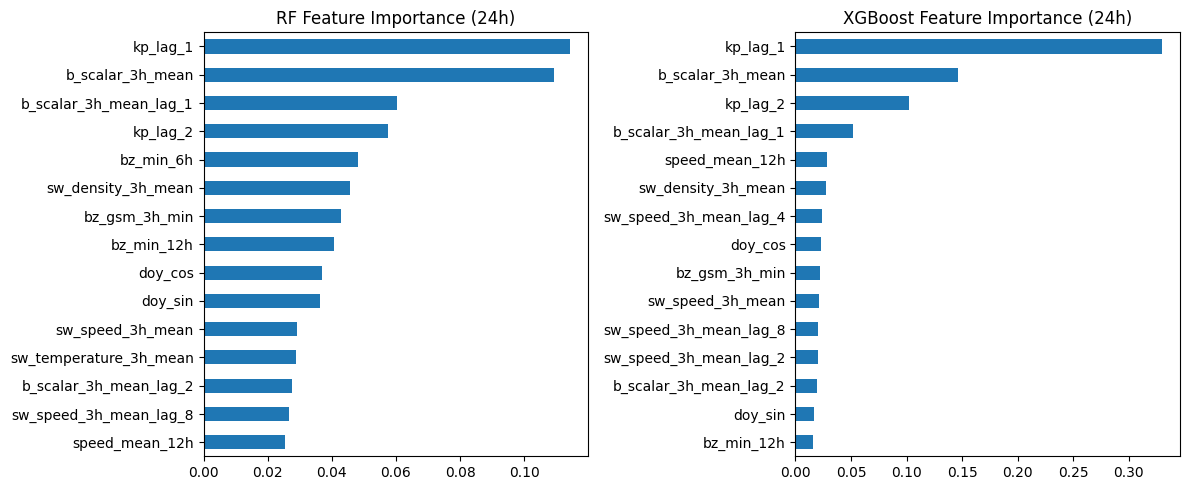

In [12]:
import matplotlib.pyplot as plt

INTERP_HORIZON = "24h"

# Use tuned params for the chosen horizon
rf_params = tuning_results[INTERP_HORIZON]["random_forest"]["best_params"]
xgb_params = tuning_results[INTERP_HORIZON]["xgboost"]["best_params"]

# Prepare data
X_trainval = features_df.loc[train_idx.union(val_idx)]
y_trainval = targets_df.loc[train_idx.union(val_idx), f"target_{INTERP_HORIZON}"]

# RF with imputation
rf_imputer = SimpleImputer(strategy="median")
X_trainval_imp = rf_imputer.fit_transform(X_trainval)

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **rf_params)
rf.fit(X_trainval_imp, y_trainval)
rf_importance = pd.Series(rf.feature_importances_, index=features_df.columns)

# XGBoost (no imputation)
xgb_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=1,
    tree_method="hist",
    **xgb_params,
)
xgb_model.fit(X_trainval, y_trainval)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=features_df.columns)

# Plot top 15
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
rf_importance.sort_values(ascending=False).head(15).iloc[::-1].plot.barh(ax=axes[0])
axes[0].set_title("RF Feature Importance (24h)")

xgb_importance.sort_values(ascending=False).head(15).iloc[::-1].plot.barh(ax=axes[1])
axes[1].set_title("XGBoost Feature Importance (24h)")

plt.tight_layout()
plt.show()


- Kp persistence dominates: kp_lag_1 (and kp_lag_2) are the top features in both RF and
    XGBoost. This shows short‑term memory of activity is the strongest signal.
  - Magnetic field magnitude matters: b_scalar_3h_mean and its lag are consistently high,
    indicating field strength is a key driver.
  - Bz and speed features contribute but are secondary (e.g., bz_min_6h, speed_mean_12h,
    sw_speed_3h_mean_*).
  - Seasonality is present but small: doy_sin/doy_cos appear lower down, so seasonal
    modulation helps but doesn’t dominate.
  - Model differences: XGBoost concentrates importance more heavily on the top few
    features, while RF spreads importance across a broader set.

  Overall: the models confirm the physics intuition—recent Kp and IMF/solar‑wind drivers
  dominate 24h predictability, with seasonal effects playing a minor role.


**Interpretability note:** importance is model-specific and not causal; use for relative ranking only.


##  Part 4b  Calibration‑Style Panels (Option A) — 24h Horizon

Binary calibration + severity‑aware calibration (mean max‑future Kp).


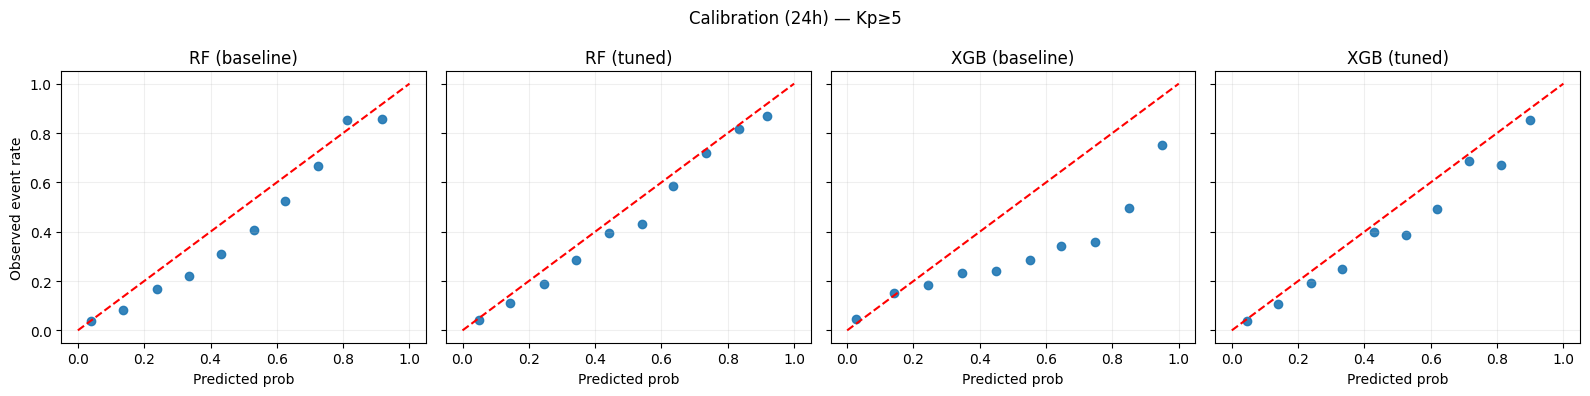

In [22]:
import matplotlib.pyplot as plt

H = "24h"
split_idx = splits["test"]
X_test = features_df.loc[split_idx]
y_test = targets_df.loc[split_idx, f"target_{H}"]

# Build continuous max‑future Kp for severity plot
master = pd.read_parquet(Path("../Data") / "processed" / "master_3h.parquet")
master = master.sort_values("timestamp_utc")
master["timestamp_utc"] = pd.to_datetime(master["timestamp_utc"])
master = master.set_index("timestamp_utc")

kp = master["kp"]
steps = 8  # 24h
future_vals = pd.concat([kp.shift(-i) for i in range(1, steps + 1)], axis=1)
max_future_kp = future_vals.max(axis=1)
max_future_kp = max_future_kp.loc[split_idx]

panel_models = [
    "random_forest_baseline",
    "random_forest_tuned",
    "xgboost_baseline",
    "xgboost_tuned",
]
panel_titles = {
    "random_forest_baseline": "RF (baseline)",
    "random_forest_tuned": "RF (tuned)",
    "xgboost_baseline": "XGB (baseline)",
    "xgboost_tuned": "XGB (tuned)",
}

def bin_stats(probs, y, bins=10):
    df = pd.DataFrame({"p": probs, "y": y})
    df["bin"] = pd.cut(df["p"], bins=bins, include_lowest=True)
    grouped = df.groupby("bin", observed=False)
    x = grouped["p"].mean()
    y = grouped["y"].mean()
    return x, y

# Build model probability dict
probs_map = {}

# Baseline models (fit quickly here with default params)
X_train_full = features_df.loc[train_idx]
y_train_full = targets_df.loc[train_idx, f"target_{H}"]

# RF baseline
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
rf_imputer = SimpleImputer(strategy="median")
X_train_imp = rf_imputer.fit_transform(X_train_full)
X_test_imp = rf_imputer.transform(X_test)
rf_base.fit(X_train_imp, y_train_full)
probs_map["random_forest_baseline"] = rf_base.predict_proba(X_test_imp)[:, 1]

# XGB baseline
xgb_base = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=1,
    tree_method="hist",
)
xgb_base.fit(X_train_full, y_train_full)
probs_map["xgboost_baseline"] = xgb_base.predict_proba(X_test)[:, 1]

# Tuned models (from A4 tuning)
rf_params = tuning_results[H]["random_forest"]["best_params"]
rf_tuned = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **rf_params)
rf_tuned.fit(X_train_imp, y_train_full)
probs_map["random_forest_tuned"] = rf_tuned.predict_proba(X_test_imp)[:, 1]

xgb_params = tuning_results[H]["xgboost"]["best_params"]
xgb_tuned = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=1,
    tree_method="hist",
    **xgb_params,
)
xgb_tuned.fit(X_train_full, y_train_full)
probs_map["xgboost_tuned"] = xgb_tuned.predict_proba(X_test)[:, 1]

# 1) Binary calibration panels
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
for ax, name in zip(axes, panel_models):
    probs = probs_map.get(name)
    if probs is None:
        ax.set_visible(False)
        continue
    x, y = bin_stats(probs, y_test, bins=10)
    ax.plot([0, 1], [0, 1], "r--", label="Perfect")
    ax.scatter(x, y, alpha=0.9)
    ax.set_title(panel_titles[name])
    ax.set_xlabel("Predicted prob")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Observed event rate")
fig.suptitle("Calibration (24h) — Kp≥5")
plt.tight_layout()
plt.show()


Interpretation is by how close each model’s points are to the diagonal:

  - Near the diagonal → well calibrated probabilities.
  - Below the diagonal → over‑confident (predicting too high).
  - Above the diagonal → under‑confident (predicting too low).

  - RF tuned is closer to the diagonal than RF baseline → better calibration.
  - XGB baseline is noticeably below the diagonal → over‑confident.
  - XGB tuned is improved but still slightly over‑confident at higher probs.

  So tuning improves calibration, especially for RF.


## Part 4c — Tuned vs Baseline Comparison

Compare tuned models to A3 baseline on the test split.


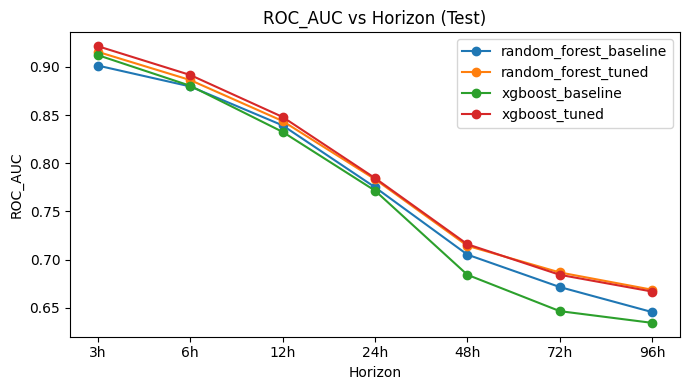

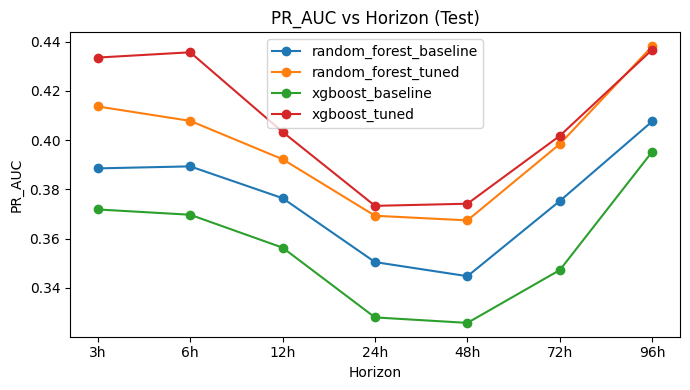

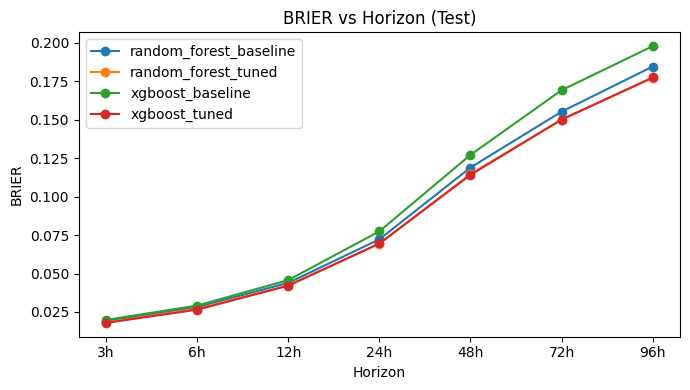

In [13]:
import matplotlib.pyplot as plt

# Load results if not already in memory
if "results_tuned_df" not in globals():
    results_tuned_df = pd.read_csv(Path("Data") / "processed" / "results_tuned.csv")

baseline_df = pd.read_csv(Path("../Data") / "processed" / "results_baseline.csv")

# Keep only test split
baseline_test = baseline_df[baseline_df["split"] == "test"].copy()
tuned_test = results_tuned_df[results_tuned_df["split"] == "test"].copy()

# Normalize model names
baseline_test["model"] = baseline_test["model"].replace({
    "random_forest": "random_forest_baseline",
    "xgboost": "xgboost_baseline",
})

tuned_test["model"] = tuned_test["model"].replace({
    "random_forest_tuned": "random_forest_tuned",
    "xgboost_tuned": "xgboost_tuned",
})

compare_df = pd.concat([baseline_test, tuned_test], ignore_index=True)

# Plot metrics vs horizon
metrics = ["roc_auc", "pr_auc", "brier"]
model_order = [
    "random_forest_baseline",
    "random_forest_tuned",
    "xgboost_baseline",
    "xgboost_tuned",
]

for metric in metrics:
    plt.figure(figsize=(7, 4))
    for model_name in model_order:
        sub = compare_df[compare_df["model"] == model_name]
        if sub.empty:
            continue
        plt.plot(sub["horizon"], sub[metric], marker="o", label=model_name)
    plt.title(f"{metric.upper()} vs Horizon (Test)")
    plt.xlabel("Horizon")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.tight_layout()
    plt.show()


In [14]:
# Improvement table vs baseline (test split)
baseline_rf = baseline_test[baseline_test["model"] == "random_forest_baseline"]
baseline_xgb = baseline_test[baseline_test["model"] == "xgboost_baseline"]
tuned_rf = tuned_test[tuned_test["model"] == "random_forest_tuned"]
tuned_xgb = tuned_test[tuned_test["model"] == "xgboost_tuned"]

def improvement_table(base_df, tuned_df, label):
    merged = base_df.merge(tuned_df, on="horizon", suffixes=("_base", "_tuned"))
    out = merged[["horizon"]].copy()
    for metric in ["roc_auc", "pr_auc", "brier"]:
        if metric == "brier":
            out[f"{metric}_delta"] = merged[f"{metric}_base"] - merged[f"{metric}_tuned"]
        else:
            out[f"{metric}_delta"] = merged[f"{metric}_tuned"] - merged[f"{metric}_base"]
    out["model"] = label
    return out

imp_rf = improvement_table(baseline_rf, tuned_rf, "random_forest")
imp_xgb = improvement_table(baseline_xgb, tuned_xgb, "xgboost")

improvement_df = pd.concat([imp_rf, imp_xgb], ignore_index=True)
improvement_df


,horizon,roc_auc_delta,pr_auc_delta,brier_delta,model
0,3h,0.014269,0.025130,0.000816,random_forest
1,6h,0.006630,0.018470,0.001090,random_forest
2,12h,0.004526,0.015806,0.001700,random_forest
3,24h,0.008326,0.018808,0.002860,random_forest
4,48h,0.009160,0.022662,0.004258,random_forest
5,72h,0.015138,0.023133,0.005152,random_forest
6,96h,0.023200,0.030507,0.007375,random_forest
7,3h,0.009273,0.061667,0.001927,xgboost
8,6h,0.011193,0.065938,0.002657,xgboost
9,12h,0.015484,0.046972,0.003634,xgboost


RandomForest (tuned vs baseline)

  - Small but consistent gains across horizons (ROC‑AUC +0.004 to +0.023, PR‑AUC +0.016 to
    +0.031).
  - Brier improves slightly (+0.0008 to +0.0074).
    → Tuning helps, but improvements are modest and steady.

  XGBoost (tuned vs baseline)

  - ROC‑AUC gains are moderate (+0.009 to +0.038), especially at 48–72h.
  - PR‑AUC gains are larger (+0.041 to +0.066), so detection of rare events improves
    notably.
  - Brier improves more strongly than RF (+0.0019 to +0.0203).
    → Tuning gives a clear boost, especially for PR‑AUC and calibration at longer horizons.

  Overall: tuned XGBoost shows the strongest improvement, particularly in PR‑AUC, while
  tuned RF gives smaller but consistent gains.


The improvements are small, especially for RandomForest. That suggests:

  - The feature set is the main limiter (not the model).
  - Tuning gives incremental gains, not a breakthrough.
  - The baseline already captures most of the available signal.


The result are obtained from L1 / near‑Earth measurements, so they’re only available shortly before
  they affect Earth (minutes to a few hours). They can’t provide true long‑lead
  anticipation by themselves. That’s why your predictability drops with horizon.

  So:

  - Short horizons (3–24h): these features are valid and useful.
  - Long horizons (48–96h): limited by physics; you need solar‑origin features (e.g., CME/
    CH catalogs) to gain lead time.

  Deep learning is unlikely to fix this (even so that i'm gonna do it to compare to the ML model.)

## Severity vs Probability (Binned) — 24h

Box/violin view of **max‑future Kp** vs predicted‑probability bins.


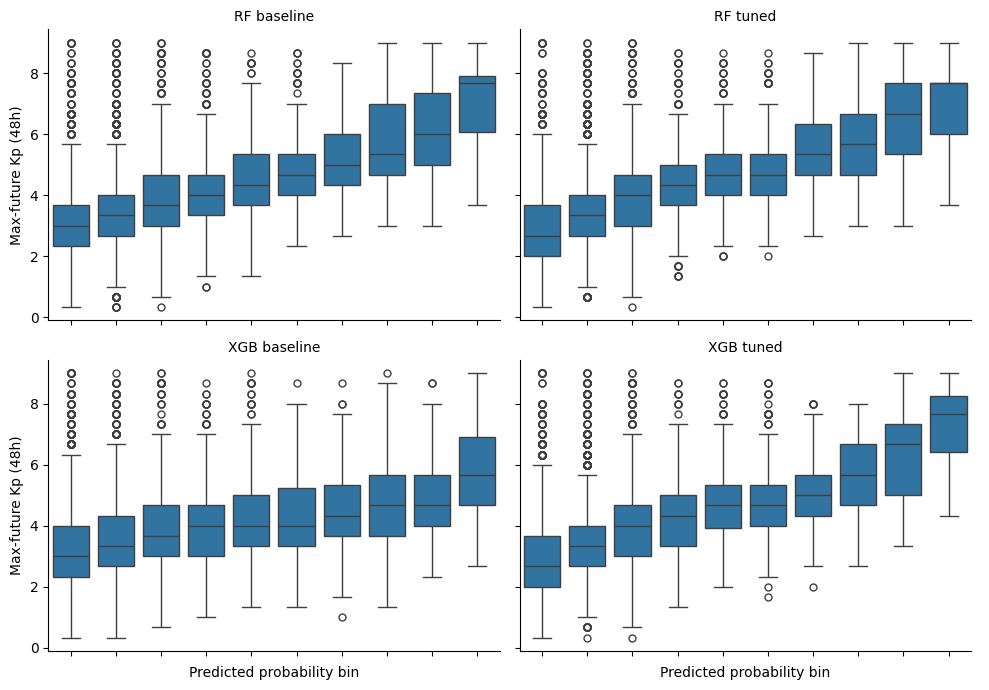

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

H = "48h"
split_idx = splits["test"]
X_test = features_df.loc[split_idx]
y_train = targets_df.loc[train_idx, f"target_{H}"]

# Max‑future Kp
master = pd.read_parquet(Path("../Data") / "processed" / "master_3h.parquet")
master = master.sort_values("timestamp_utc")
master["timestamp_utc"] = pd.to_datetime(master["timestamp_utc"])
master = master.set_index("timestamp_utc")
kp = master["kp"]
steps = 16  # 48h = 16*3h
future_vals = pd.concat([kp.shift(-i) for i in range(1, steps + 1)], axis=1)
max_future_kp = future_vals.max(axis=1).loc[split_idx]

# --- models ---
# RF baseline
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
rf_imputer = SimpleImputer(strategy="median")
X_train_imp = rf_imputer.fit_transform(features_df.loc[train_idx])
X_test_imp = rf_imputer.transform(X_test)
rf_base.fit(X_train_imp, y_train)
probs_rf_base = rf_base.predict_proba(X_test_imp)[:, 1]

# RF tuned
rf_params = tuning_results[H]["random_forest"]["best_params"]
rf_tuned = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **rf_params)
rf_tuned.fit(X_train_imp, y_train)
probs_rf_tuned = rf_tuned.predict_proba(X_test_imp)[:, 1]

# XGB baseline
xgb_base = xgb.XGBClassifier(
  random_state=RANDOM_STATE, eval_metric="logloss",
  n_jobs=1, tree_method="hist"
)
xgb_base.fit(features_df.loc[train_idx], y_train)
probs_xgb_base = xgb_base.predict_proba(X_test)[:, 1]

# XGB tuned
xgb_params = tuning_results[H]["xgboost"]["best_params"]
xgb_tuned = xgb.XGBClassifier(
  random_state=RANDOM_STATE, eval_metric="logloss",
  n_jobs=1, tree_method="hist", **xgb_params
)
xgb_tuned.fit(features_df.loc[train_idx], y_train)
probs_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

# --- build long dataframe ---
def build_df(probs, label):
  df = pd.DataFrame({"prob": probs, "max_kp": max_future_kp.values})
  df["bin"] = pd.cut(df["prob"], bins=np.linspace(0, 1, 11), include_lowest=True)
  df["model"] = label
  return df

df_plot = pd.concat([
  build_df(probs_rf_base, "RF baseline"),
  build_df(probs_rf_tuned, "RF tuned"),
  build_df(probs_xgb_base, "XGB baseline"),
  build_df(probs_xgb_tuned, "XGB tuned"),
])

# Facet plot (4 panels)
g = sns.catplot(
  data=df_plot,
  x="bin", y="max_kp",
  col="model",
  kind="box",
  col_wrap=2,
  height=3.5,
  aspect=1.4,
  sharey=True
)
g.set_xticklabels(rotation=45, ha="right")
g.set_titles("{col_name}")
g.set_axis_labels("Predicted probability bin", f"Max‑future Kp ({H})")
plt.tight_layout()
plt.show()


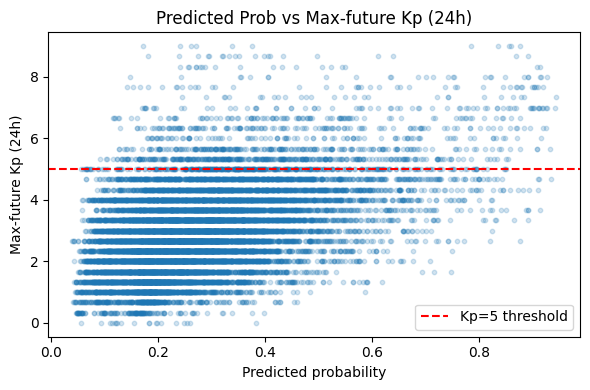

In [29]:
plt.figure(figsize=(6, 4))
plt.scatter(df_plot["prob"], df_plot["max_kp"], alpha=0.2, s=10)
plt.axhline(5, color="red", linestyle="--", label="Kp=5 threshold")
plt.xlabel("Predicted probability")
plt.ylabel("Max-future Kp (24h)")
plt.title("Predicted Prob vs Max-future Kp (24h)")
plt.legend()
plt.tight_layout()
plt.show()
